In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, classification_report,
                             confusion_matrix)
from sklearn.preprocessing import StandardScaler
import joblib
import os

# Load data
X_train = pd.read_csv('../data/processed/X_train_eng.csv')
X_val   = pd.read_csv('../data/processed/X_val_eng.csv')
X_test  = pd.read_csv('../data/processed/X_test_eng.csv')

yc_train = pd.read_csv('../data/processed/yc_train.csv').squeeze()
yc_val   = pd.read_csv('../data/processed/yc_val.csv').squeeze()
yc_test  = pd.read_csv('../data/processed/yc_test.csv').squeeze()

with open('../data/processed/feature_cols_engineered.json') as f:
    feature_cols = json.load(f)

print(f"X_train shape : {X_train.shape}")
print(f"X_val shape   : {X_val.shape}")
print(f"X_test shape  : {X_test.shape}")
print(f"\nClass distribution in train:")
print(yc_train.value_counts())

X_train shape : (283521, 38)
X_val shape   : (60559, 38)
X_test shape  : (60720, 38)

Class distribution in train:
emi_eligibility
0    219132
2     52140
1     12249
Name: count, dtype: int64


In [2]:
# Scale features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

# Save scaler for Streamlit app later
os.makedirs('../models', exist_ok=True)
joblib.dump(scaler, '../models/scaler.pkl')

print("Scaling done")
print(f"Mean of first feature before scaling : {X_train.iloc[:,0].mean():.2f}")
print(f"Mean of first feature after scaling  : {X_train_scaled[:,0].mean():.4f}")

Scaling done
Mean of first feature before scaling : 38.87
Mean of first feature after scaling  : 0.0000


In [3]:
# Evaluation function
def evaluate_classifier(name, model, X_tr, y_tr, X_v, y_v):
    # Predictions
    y_pred_val  = model.predict(X_v)
    y_pred_train = model.predict(X_tr)

    # Metrics
    results = {
        'Model'        : name,
        'Train Acc'    : round(accuracy_score(y_tr, y_pred_train) * 100, 2),
        'Val Acc'      : round(accuracy_score(y_v, y_pred_val) * 100, 2),
        'Precision'    : round(precision_score(y_v, y_pred_val, average='weighted') * 100, 2),
        'Recall'       : round(recall_score(y_v, y_pred_val, average='weighted') * 100, 2),
        'F1 Score'     : round(f1_score(y_v, y_pred_val, average='weighted') * 100, 2),
        'ROC AUC'      : round(roc_auc_score(y_v, model.predict_proba(X_v),
                               multi_class='ovr', average='weighted') * 100, 2)
    }

    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    for k, v in results.items():
        if k != 'Model':
            print(f"  {k:<15} : {v}")
    print(f"\nClassification Report:")
    print(classification_report(y_v, y_pred_val,
          target_names=['Not_Eligible', 'High_Risk', 'Eligible']))

    return results

print("Evaluation function ready")

Evaluation function ready


In [4]:
# logistic regression
print("Training Logistic Regression...")

lr_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42,
    n_jobs=-1
)

lr_model.fit(X_train_scaled, yc_train)
lr_results = evaluate_classifier('Logistic Regression', lr_model,
                                  X_train_scaled, yc_train,
                                  X_val_scaled, yc_val)

print("\nLogistic Regression training complete")

Training Logistic Regression...

  Logistic Regression
  Train Acc       : 80.21
  Val Acc         : 80.19
  Precision       : 92.91
  Recall          : 80.19
  F1 Score        : 85.09
  ROC AUC         : 96.47

Classification Report:
              precision    recall  f1-score   support

Not_Eligible       0.99      0.82      0.90     46806
   High_Risk       0.15      0.71      0.25      2616
    Eligible       0.86      0.75      0.80     11137

    accuracy                           0.80     60559
   macro avg       0.67      0.76      0.65     60559
weighted avg       0.93      0.80      0.85     60559


Logistic Regression training complete


In [5]:
# decision tree
print("Training Decision Tree...")

dt_model = DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=50,
    min_samples_leaf=20,
    class_weight='balanced',
    random_state=42
)

dt_model.fit(X_train, yc_train)
dt_results = evaluate_classifier('Decision Tree', dt_model,
                                  X_train, yc_train,
                                  X_val, yc_val)

print("\nDecision Tree training complete")

Training Decision Tree...

  Decision Tree
  Train Acc       : 89.31
  Val Acc         : 88.81
  Precision       : 95.7
  Recall          : 88.81
  F1 Score        : 91.32
  ROC AUC         : 98.46

Classification Report:
              precision    recall  f1-score   support

Not_Eligible       1.00      0.90      0.95     46806
   High_Risk       0.27      0.87      0.41      2616
    Eligible       0.95      0.83      0.88     11137

    accuracy                           0.89     60559
   macro avg       0.74      0.87      0.75     60559
weighted avg       0.96      0.89      0.91     60559


Decision Tree training complete


In [6]:
# Random forest
print("Training Random Forest... (may take 2-3 minutes)")

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_split=50,
    min_samples_leaf=20,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, yc_train)
rf_results = evaluate_classifier('Random Forest', rf_model,
                                  X_train, yc_train,
                                  X_val, yc_val)

print("\nRandom Forest training complete")

Training Random Forest... (may take 2-3 minutes)

  Random Forest
  Train Acc       : 91.31
  Val Acc         : 90.03
  Precision       : 95.56
  Recall          : 90.03
  F1 Score        : 92.04
  ROC AUC         : 99.21

Classification Report:
              precision    recall  f1-score   support

Not_Eligible       1.00      0.92      0.95     46806
   High_Risk       0.30      0.85      0.44      2616
    Eligible       0.94      0.85      0.89     11137

    accuracy                           0.90     60559
   macro avg       0.74      0.87      0.76     60559
weighted avg       0.96      0.90      0.92     60559


Random Forest training complete


In [7]:
# XGBoost
# Install if not already installed
# pip install xgboost

from xgboost import XGBClassifier

print("Training XGBoost... (may take 2-3 minutes)")

# Handle class imbalance manually for XGBoost
from sklearn.utils.class_weight import compute_sample_weight
sample_weights = compute_sample_weight(class_weight='balanced', y=yc_train)

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, yc_train, sample_weight=sample_weights)
xgb_results = evaluate_classifier('XGBoost', xgb_model,
                                   X_train, yc_train,
                                   X_val, yc_val)

print("\nXGBoost training complete")

Training XGBoost... (may take 2-3 minutes)

  XGBoost
  Train Acc       : 92.97
  Val Acc         : 92.29
  Precision       : 96.74
  Recall          : 92.29
  F1 Score        : 93.8
  ROC AUC         : 99.65

Classification Report:
              precision    recall  f1-score   support

Not_Eligible       1.00      0.93      0.96     46806
   High_Risk       0.36      0.96      0.53      2616
    Eligible       0.98      0.88      0.93     11137

    accuracy                           0.92     60559
   macro avg       0.78      0.92      0.81     60559
weighted avg       0.97      0.92      0.94     60559


XGBoost training complete


                 Model  Val Acc  F1 Score  ROC AUC
0  Logistic Regression    80.19     85.09    96.47
1        Decision Tree    88.81     91.32    98.46
2        Random Forest    90.03     92.04    99.21
3              XGBoost    92.29     93.80    99.65


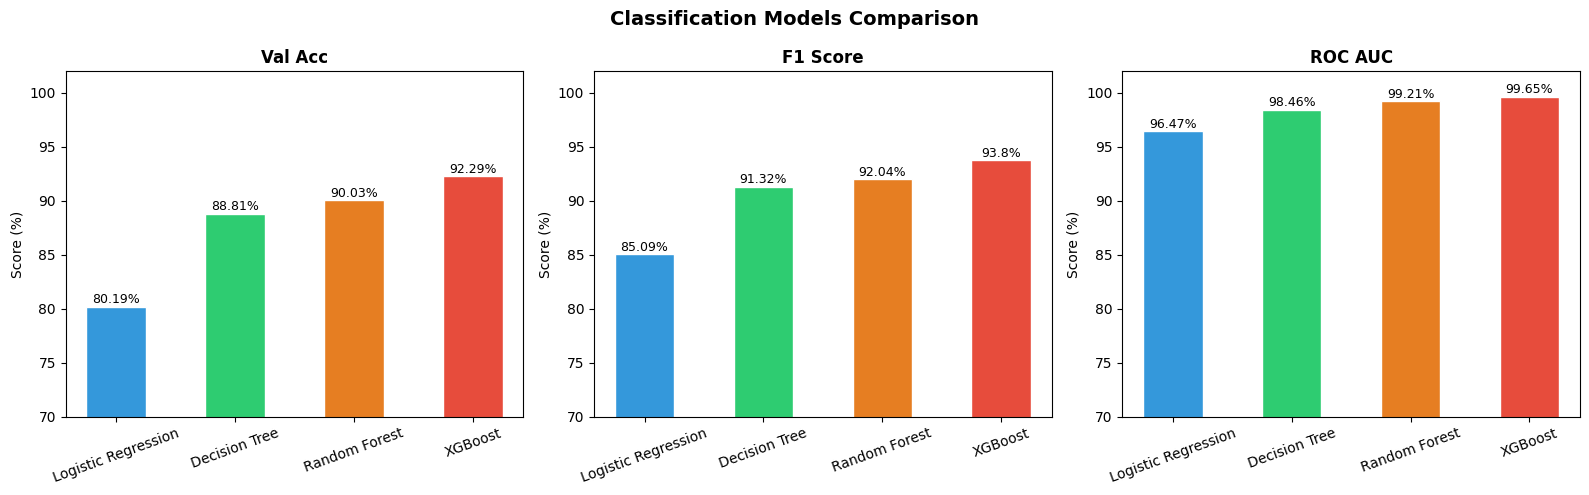

In [8]:
# Compare models
results_list = [lr_results, dt_results, rf_results, xgb_results]
results_df = pd.DataFrame(results_list)

print(results_df[['Model', 'Val Acc', 'F1 Score', 'ROC AUC']])

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics = ['Val Acc', 'F1 Score', 'ROC AUC']
colors  = ['#3498db', '#2ecc71', '#e67e22', '#e74c3c']

for i, metric in enumerate(metrics):
    bars = axes[i].bar(
        results_df['Model'],
        results_df[metric],
        color=colors,
        edgecolor='white',
        width=0.5
    )
    axes[i].set_title(metric, fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Score (%)')
    axes[i].set_ylim(70, 102)
    axes[i].tick_params(axis='x', rotation=20)
    for bar, val in zip(bars, results_df[metric]):
        axes[i].text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            f'{val}%',
            ha='center', fontsize=9
        )

plt.suptitle('Classification Models Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/classification_comparison.png', dpi=120)
plt.show()

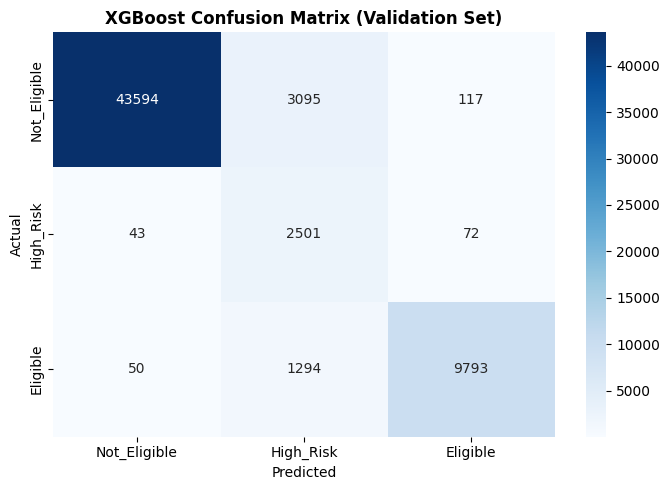

In [9]:
fig, ax = plt.subplots(figsize=(7, 5))

cm = confusion_matrix(yc_val, xgb_model.predict(X_val))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Not_Eligible', 'High_Risk', 'Eligible'],
    yticklabels=['Not_Eligible', 'High_Risk', 'Eligible'],
    ax=ax
)
ax.set_title('XGBoost Confusion Matrix (Validation Set)', fontsize=12, fontweight='bold')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.savefig('../data/processed/xgb_confusion_matrix.png', dpi=120)
plt.show()

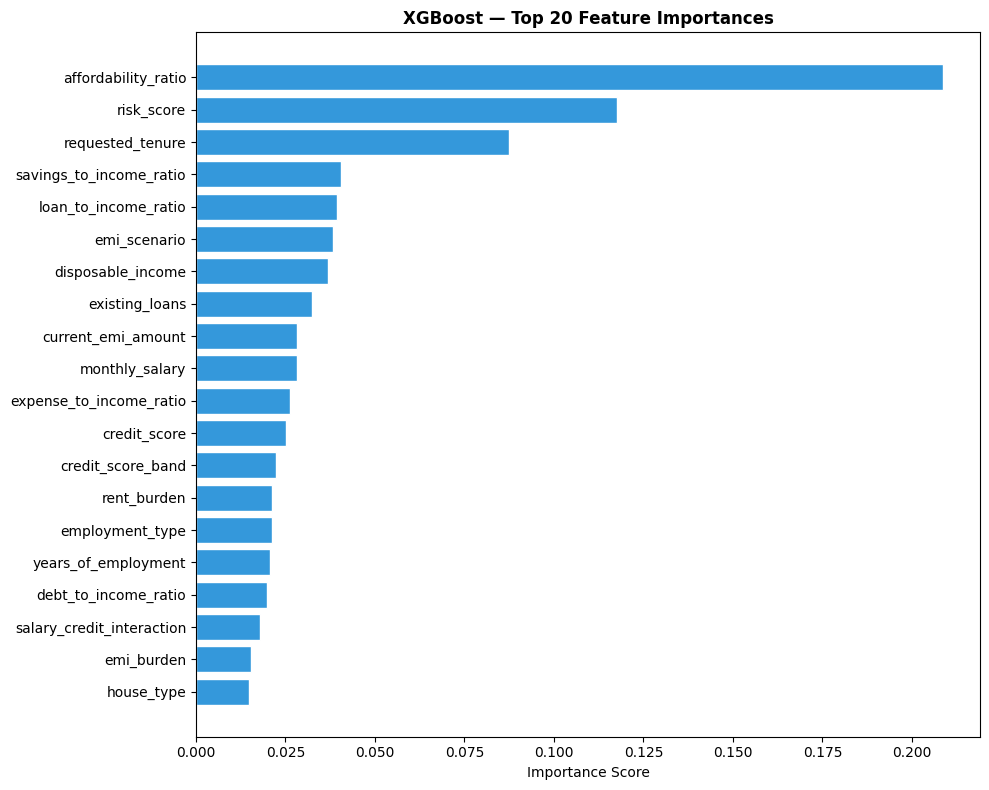

Top 10 most important features:
                feature  importance
    affordability_ratio    0.208574
             risk_score    0.117499
       requested_tenure    0.087335
savings_to_income_ratio    0.040422
   loan_to_income_ratio    0.039254
           emi_scenario    0.038290
      disposable_income    0.036874
         existing_loans    0.032514
     current_emi_amount    0.028244
         monthly_salary    0.028226


In [10]:
fig, ax = plt.subplots(figsize=(10, 8))

importance_df = pd.DataFrame({
    'feature'   : feature_cols,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False).head(20)

bars = ax.barh(
    importance_df['feature'],
    importance_df['importance'],
    color='#3498db',
    edgecolor='white'
)
ax.set_title('XGBoost — Top 20 Feature Importances', fontsize=12, fontweight='bold')
ax.set_xlabel('Importance Score')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../data/processed/xgb_feature_importance.png', dpi=120)
plt.show()

print("Top 10 most important features:")
print(importance_df.head(10)[['feature', 'importance']].to_string(index=False))

In [11]:
# XGBoost is our best model — save it
joblib.dump(xgb_model, '../models/best_classifier.pkl')

print("Best classification model saved: XGBoost")
print(f"Saved to : ../models/best_classifier.pkl")
print(f"\nFinal Test Set Evaluation:")

y_test_pred = xgb_model.predict(X_test)
print(f"Test Accuracy : {accuracy_score(yc_test, y_test_pred)*100:.2f}%")
print(f"Test F1 Score : {f1_score(yc_test, y_test_pred, average='weighted')*100:.2f}%")
print(classification_report(yc_test, y_test_pred,
      target_names=['Not_Eligible', 'High_Risk', 'Eligible']))

Best classification model saved: XGBoost
Saved to : ../models/best_classifier.pkl

Final Test Set Evaluation:
Test Accuracy : 92.27%
Test F1 Score : 93.78%
              precision    recall  f1-score   support

Not_Eligible       1.00      0.93      0.96     46930
   High_Risk       0.36      0.96      0.53      2623
    Eligible       0.98      0.89      0.93     11167

    accuracy                           0.92     60720
   macro avg       0.78      0.92      0.81     60720
weighted avg       0.97      0.92      0.94     60720

